# Midterm Exam - Model A - Matthew Shaver

## Setup

In [1]:
from pathlib import Path
import json
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import HTML, display
from PIL import Image
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import MobileNet_V2_Weights, mobilenet_v2

print('PyTorch version:', torch.__version__)

PyTorch version: 2.1.2+cu121


In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'notebooks').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / 'notebooks').exists():
    raise FileNotFoundError('Open this notebook from the project repository.')

print('Project root:', PROJECT_ROOT)

Project root: C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-6165-Sum-2026-Take-Home-Exam


In [3]:
SEED = 42
IMAGE_SIZE = 128
BATCH_SIZE = 100
NUM_WORKERS = 0
PROGRESS_EVERY_BATCHES = 10
CLASS_NAMES = ('cats', 'dogs')

LEARNING_RATE = 0.001
EPOCHS = 30
EARLY_STOPPING_PATIENCE = 8

SPLIT_DIR = PROJECT_ROOT / 'data' / 'splits'
MODELS_DIR = PROJECT_ROOT / 'models'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'model_a'
BEST_MODEL_PATH = MODELS_DIR / 'model_a_mobilenetv2_best.pt'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if not torch.cuda.is_available():
    raise RuntimeError('CUDA is required. Install the CUDA-enabled PyTorch packages from requirements.txt.')

DEVICE = torch.device('cuda')
PIN_MEMORY = True

print('Image size:', IMAGE_SIZE)
print('Batch size:', BATCH_SIZE)
print('Classes:', CLASS_NAMES)
print('Saved model:', BEST_MODEL_PATH)
print('Device:', DEVICE)
print('GPU:', torch.cuda.get_device_name(0))

Image size: 128
Batch size: 100
Classes: ('cats', 'dogs')
Saved model: C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-6165-Sum-2026-Take-Home-Exam\models\model_a_mobilenetv2_best.pt
Device: cuda
GPU: NVIDIA GeForce RTX 4070 SUPER


## Dataset

In [4]:
train_table = pd.read_csv(SPLIT_DIR / 'train_split.csv')
validation_table = pd.read_csv(SPLIT_DIR / 'val_split.csv')
test_table = pd.read_csv(SPLIT_DIR / 'test_split.csv')

split_tables = {
    'Training': train_table,
    'Validation': validation_table,
    'Test': test_table,
}

for split_name, split_table in split_tables.items():
    class_counts = split_table['label'].value_counts().sort_index()
    if set(class_counts.index) != set(CLASS_NAMES):
        raise ValueError(f'{split_name} split must contain cats and dogs.')

    print(split_name, 'images:', len(split_table))
    print(class_counts)
    print()

Training images: 14831
label
cats    7419
dogs    7412
Name: count, dtype: int64

Validation images: 2618
label
cats    1310
dogs    1308
Name: count, dtype: int64

Test images: 7479
label
cats    3741
dogs    3738
Name: count, dtype: int64



## Prepare Data

Resize each image to the same size and apply a small horizontal-flip augmentation to training images.

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

In [6]:
class DogsVsCatsDataset(Dataset):
    def __init__(self, records, transform):
        self.records = records.reset_index(drop=True)
        self.transform = transform
        self.class_to_index = {'cats': 0, 'dogs': 1}

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        record = self.records.iloc[index]
        image_path = Path(record['image_path'])

        with Image.open(image_path) as image:
            image = image.convert('RGB')

        image = self.transform(image)
        label = self.class_to_index[record['label']]
        return image, torch.tensor(label, dtype=torch.float32)

## Create Data Loaders

The training loader shuffles images. Validation and test loaders keep their original order.

In [7]:
train_dataset = DogsVsCatsDataset(train_table, train_transform)
validation_dataset = DogsVsCatsDataset(validation_table, evaluation_transform)
test_dataset = DogsVsCatsDataset(test_table, evaluation_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print('Training batches:', len(train_loader))
print('Validation batches:', len(validation_loader))
print('Test batches:', len(test_loader))

Training batches: 149
Validation batches: 27
Test batches: 75


## Build MobileNetV2

Use the same pretrained MobileNetV2 approach as Assignment 1. Keep the MobileNetV2 feature layers frozen and train only the final binary classifier.

In [8]:
class MobileNetV2Classifier(nn.Module):
    def __init__(self, weights):
        super().__init__()
        self.model = mobilenet_v2(weights=weights)

        for parameter in self.model.features.parameters():
            parameter.requires_grad = False

        input_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(input_features, 1)

    def forward(self, images):
        return self.model(images).squeeze(1)

In [9]:
model = MobileNetV2Classifier(MobileNet_V2_Weights.DEFAULT).to(DEVICE)

In [10]:
total_parameters = sum(parameter.numel() for parameter in model.parameters())
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(model)
print('Total parameters:', total_parameters)
print('Trainable parameters:', trainable_parameters)
print('Model device:', next(model.parameters()).device)

MobileNetV2Classifier(
  (model): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, kernel

In [11]:
def format_duration(seconds):
    seconds = max(0, int(round(seconds)))
    minutes, seconds = divmod(seconds, 60)
    hours, minutes = divmod(minutes, 60)

    if hours > 0:
        return f'{hours}h {minutes}m {seconds}s'
    if minutes > 0:
        return f'{minutes}m {seconds}s'
    return f'{seconds}s'


def update_epoch_progress(
    progress_display,
    epoch_number,
    phase_name,
    batch_number,
    total_batches,
    average_epoch_seconds,
):
    percent_complete = 100 * batch_number / total_batches

    if average_epoch_seconds is None:
        time_text = 'Avg: calculating... | Est. completion: calculating...'
    else:
        remaining_epochs = EPOCHS - epoch_number + (1 - percent_complete / 100)
        estimated_seconds = average_epoch_seconds * remaining_epochs
        time_text = (
            f'Avg: {format_duration(average_epoch_seconds)} | '
            f'Est. completion: {format_duration(estimated_seconds)}'
        )

    progress_html = HTML(
        f'''<div style="display: flex; align-items: center; gap: 10px; max-width: 1100px; margin: 8px 0; color: #166534; font-family: sans-serif; font-size: 12px; font-weight: 600; white-space: nowrap;">
        <span>Epoch {epoch_number}/{EPOCHS} | {phase_name}</span>
        <div style="flex: 1; min-width: 80px; height: 12px; background: #dcfce7; border: 1px solid #86efac; border-radius: 6px; overflow: hidden;">
            <div style="width: {percent_complete:.0f}%; height: 100%; background: #16a34a;"></div>
        </div>
        <span>{batch_number}/{total_batches} | {percent_complete:.0f}%</span>
        <span>{time_text}</span>
        </div>'''
    )

    if progress_display is None:
        display(progress_html)
    else:
        progress_display.update(progress_html)

In [12]:
def train_one_epoch(
    model,
    loader,
    loss_function,
    optimizer,
    epoch_number,
    progress_display,
    average_epoch_seconds,
):
    model.train()
    total_loss = 0.0
    correct_predictions = 0
    total_images = 0
    total_batches = len(loader)

    for batch_number, (images, labels) in enumerate(loader, start=1):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images).reshape(-1)
        loss = loss_function(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        predictions = (torch.sigmoid(logits) >= 0.5).float()
        correct_predictions += (predictions == labels).sum().item()
        total_images += images.size(0)

        if (
            batch_number == 1
            or batch_number % PROGRESS_EVERY_BATCHES == 0
            or batch_number == total_batches
        ):
            update_epoch_progress(
                progress_display,
                epoch_number,
                'Training',
                batch_number,
                total_batches,
                average_epoch_seconds,
            )

    average_loss = total_loss / total_images
    accuracy = correct_predictions / total_images
    return average_loss, accuracy

In [13]:
def evaluate(
    model,
    loader,
    loss_function,
    epoch_number,
    progress_display,
    average_epoch_seconds,
):
    model.eval()
    total_loss = 0.0
    correct_predictions = 0
    total_images = 0
    total_batches = len(loader)

    with torch.no_grad():
        for batch_number, (images, labels) in enumerate(loader, start=1):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            logits = model(images).reshape(-1)
            loss = loss_function(logits, labels)

            total_loss += loss.item() * images.size(0)
            predictions = (torch.sigmoid(logits) >= 0.5).float()
            correct_predictions += (predictions == labels).sum().item()
            total_images += images.size(0)

            if (
                batch_number == 1
                or batch_number % PROGRESS_EVERY_BATCHES == 0
                or batch_number == total_batches
            ):
                update_epoch_progress(
                    progress_display,
                    epoch_number,
                    'Validation',
                    batch_number,
                    total_batches,
                    average_epoch_seconds,
                )

    average_loss = total_loss / total_images
    accuracy = correct_predictions / total_images
    return average_loss, accuracy

## Train MobileNetV2

Train the MobileNetV2 classifier on CUDA and save the version with the lowest validation loss.

In [14]:
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [15]:
history = []
best_validation_loss = float('inf')
epochs_without_improvement = 0
progress_display = display(HTML(''), display_id=True)

for epoch in range(EPOCHS):
    epoch_number = epoch + 1

    if history:
        average_epoch_seconds = sum(
            record['epoch_seconds']
            for record in history
        ) / len(history)
    else:
        average_epoch_seconds = None

    epoch_start = time.perf_counter()

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        loss_function,
        optimizer,
        epoch_number,
        progress_display,
        average_epoch_seconds,
    )
    validation_loss, validation_accuracy = evaluate(
        model,
        validation_loader,
        loss_function,
        epoch_number,
        progress_display,
        average_epoch_seconds,
    )
    epoch_seconds = time.perf_counter() - epoch_start

    epoch_results = {
        'epoch': epoch_number,
        'train_loss': train_loss,
        'train_accuracy': train_accuracy,
        'validation_loss': validation_loss,
        'validation_accuracy': validation_accuracy,
        'epoch_seconds': epoch_seconds,
    }
    history.append(epoch_results)

    average_epoch_seconds = sum(
        record['epoch_seconds']
        for record in history
    ) / len(history)
    estimated_seconds = average_epoch_seconds * (EPOCHS - epoch_number)

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
    else:
        epochs_without_improvement += 1

    print(
        f'Epoch {epoch_number}/{EPOCHS} complete | '
        f'train loss: {train_loss:.4f} | '
        f'train accuracy: {train_accuracy:.4f} | '
        f'validation loss: {validation_loss:.4f} | '
        f'validation accuracy: {validation_accuracy:.4f} | '
        f'time: {format_duration(epoch_seconds)} | '
        f'avg epoch: {format_duration(average_epoch_seconds)} | '
        f'est. time to completion: {format_duration(estimated_seconds)}',
        flush=True,
    )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print('Early stopping triggered.', flush=True)
        break

c:\Users\Matt Shaver\OneDrive\Desktop\DSBA-6165-Sum-2026-Take-Home-Exam\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 1/30 complete | train loss: 0.3285 | train accuracy: 0.8817 | validation loss: 0.2314 | validation accuracy: 0.9152 | time: 31s | avg epoch: 31s | est. time to completion: 14m 57s
Epoch 2/30 complete | train loss: 0.2288 | train accuracy: 0.9111 | validation loss: 0.1960 | validation accuracy: 0.9228 | time: 33s | avg epoch: 32s | est. time to completion: 14m 51s
Epoch 3/30 complete | train loss: 0.2056 | train accuracy: 0.9163 | validation loss: 0.1873 | validation accuracy: 0.9251 | time: 34s | avg epoch: 33s | est. time to completion: 14m 39s
Epoch 4/30 complete | train loss: 0.1948 | train accuracy: 0.9204 | validation loss: 0.1757 | validation accuracy: 0.9305 | time: 32s | avg epoch: 32s | est. time to completion: 14m 5s
Epoch 5/30 complete | train loss: 0.1898 | train accuracy: 0.9230 | validation loss: 0.1730 | validation accuracy: 0.9290 | time: 35s | avg epoch: 33s | est. time to completion: 13m 44s
Epoch 6/30 complete | train loss: 0.1819 | train accuracy: 0.9239 | val

In [16]:
history_table = pd.DataFrame(history)

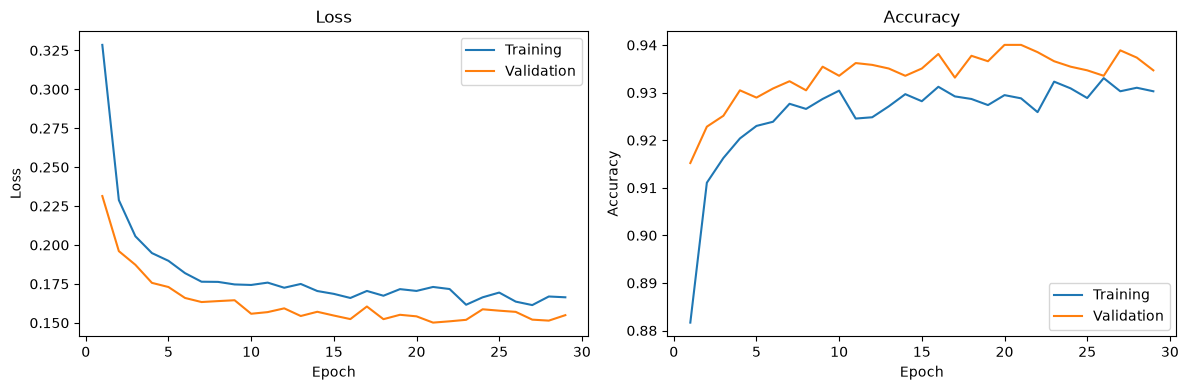

In [17]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_table['epoch'], history_table['train_loss'], label='Training')
plt.plot(history_table['epoch'], history_table['validation_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_table['epoch'], history_table['train_accuracy'], label='Training')
plt.plot(history_table['epoch'], history_table['validation_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_history.png', dpi=200)
plt.show()

## Test MobileNetV2

Load the saved MobileNetV2 classifier and evaluate it on the untouched test split.

In [18]:
test_model = MobileNetV2Classifier(weights=None).to(DEVICE)
test_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
test_model.eval()

print('Loaded saved model:', BEST_MODEL_PATH)

Loaded saved model: C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-6165-Sum-2026-Take-Home-Exam\models\model_a_mobilenetv2_best.pt


In [19]:
all_probabilities = []
all_targets = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        logits = test_model(images).reshape(-1)
        probabilities = torch.sigmoid(logits).cpu()

        all_probabilities.extend(probabilities.tolist())
        all_targets.extend(labels.tolist())

predictions = [1 if probability >= 0.5 else 0 for probability in all_probabilities]
targets = [int(target) for target in all_targets]

false_positive_rate, true_positive_rate, _ = roc_curve(targets, all_probabilities)
test_metrics = {
    'accuracy': accuracy_score(targets, predictions),
    'precision': precision_score(targets, predictions, zero_division=0),
    'recall': recall_score(targets, predictions, zero_division=0),
    'f1': f1_score(targets, predictions, zero_division=0),
    'roc_auc': auc(false_positive_rate, true_positive_rate),
}

print(pd.Series(test_metrics).round(4))

accuracy     0.9356
precision    0.9400
recall       0.9304
f1           0.9352
roc_auc      0.9849
dtype: float64


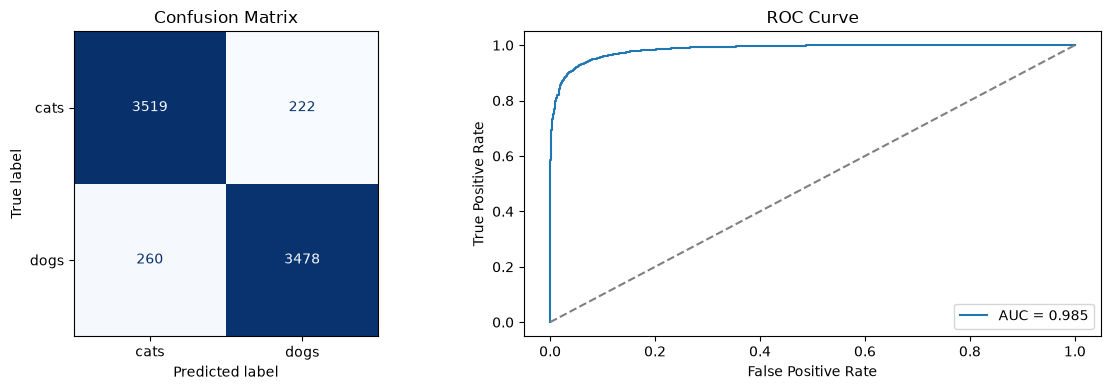

Results saved to: C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-6165-Sum-2026-Take-Home-Exam\outputs\model_a


: 

In [ ]:
prediction_table = pd.DataFrame({
    'actual': [CLASS_NAMES[target] for target in targets],
    'probability_dog': all_probabilities,
    'predicted': [CLASS_NAMES[prediction] for prediction in predictions],
})

prediction_table.to_csv(OUTPUT_DIR / 'test_predictions.csv', index=False)
(OUTPUT_DIR / 'test_metrics.json').write_text(
    json.dumps(test_metrics, indent=2),
    encoding='utf-8',
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(
    confusion_matrix(targets, predictions),
    display_labels=CLASS_NAMES,
).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

axes[1].plot(false_positive_rate, true_positive_rate, label=f"AUC = {test_metrics['roc_auc']:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'test_evaluation.png', dpi=200)
plt.show()

print('Results saved to:', OUTPUT_DIR)